In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sklearn.preprocessing import LabelEncoder

In [48]:
df = pd.read_csv('data/train_test_dataset.csv', 
                 on_bad_lines='skip',  # Skip problematic lines
                 engine='python',
                 delimiter= ";")      # Use Python engine (more forgiving)

df.head()

,ref,subType,brand,itemDescriptionEN,itemCapacity,itemCapacityUnits,packType,nameEN,hsCodeNav,weightConfirmed,dimensionsConfirmed,weight,width,height,depth
0,000012SE,1,SE,Daeses Firming Body Milk,200,2,0,Firming Care,33049900,1,1,261,8,17,5
1,000010SE,1,SE,Daeses Firming Mask,75,2,0,Anti-Ageing Masks,33049900,1,1,112,4,17,4
2,000014SE,1,SE,Hidraderm Hyal Moisturizing Body Milk,400,2,0,Dryness & Dehydration,33049900,1,1,452,8,22,5
3,000015SE,1,SE,Hidraderm Cleansing Milk,200,2,0,Sensitive Skin,33049900,1,1,261,8,17,5
4,000019SE,1,SE,Hidraloe Aloe Vera Gel,250,2,0,Dryness & Dehydration,33049900,1,1,301,6,18,6


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21852 entries, 0 to 21851
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ref                  21852 non-null  object
 1   subType              21852 non-null  int64 
 2   brand                21850 non-null  object
 3   itemDescriptionEN    21852 non-null  object
 4   itemCapacity         21852 non-null  object
 5   itemCapacityUnits    21852 non-null  int64 
 6   packType             21852 non-null  int64 
 7   nameEN               21852 non-null  object
 8   hsCodeNav            21852 non-null  int64 
 9   weightConfirmed      21852 non-null  int64 
 10  dimensionsConfirmed  21852 non-null  int64 
 11  weight               21852 non-null  int64 
 12  width                21852 non-null  int64 
 13  height               21852 non-null  int64 
 14  depth                21852 non-null  int64 
dtypes: int64(10), object(5)
memory usage: 2.5+ MB


In [50]:
df.describe()

,subType,itemCapacityUnits,packType,hsCodeNav,weightConfirmed,dimensionsConfirmed,weight,width,height,depth
count,21852.000000,21852.000000,21852.000000,2.185200e+04,21852.0,21852.0,21852.000000,21852.000000,21852.000000,21852.000000
mean,2.988514,2.342989,0.504439,3.420029e+07,1.0,1.0,200.187580,7.079947,13.423348,4.701309
std,5.541379,1.485831,2.076613,9.754281e+06,0.0,0.0,246.967441,4.715907,5.182817,2.664731
min,1.000000,0.000000,0.000000,2.106102e+07,1.0,1.0,1.000000,1.000000,1.000000,1.000000
25%,1.000000,2.000000,0.000000,3.304200e+07,1.0,1.0,56.000000,4.000000,10.000000,3.000000
50%,1.000000,2.000000,0.000000,3.304990e+07,1.0,1.0,134.000000,6.000000,13.000000,4.000000
75%,3.000000,2.000000,0.000000,3.304990e+07,1.0,1.0,255.000000,8.000000,17.000000,6.000000
max,91.000000,14.000000,16.000000,9.619009e+07,1.0,1.0,5300.000000,140.000000,165.000000,56.000000


In [51]:
# Create a copy of your dataframe
df_encoded = df.copy()

# Columns to encode
columns_to_encode = ['brand', 'nameEN', 'hsCodeNav']

# Create label encoders for each column
label_encoders = {}

for column in columns_to_encode:
    le = LabelEncoder()
    df_encoded[column] = le.fit_transform(df[column].astype(str))
    label_encoders[column] = le  # Store encoder for future use

df_encoded.head()

,ref,subType,brand,itemDescriptionEN,itemCapacity,itemCapacityUnits,packType,nameEN,hsCodeNav,weightConfirmed,dimensionsConfirmed,weight,width,height,depth
0,000012SE,1,436,Daeses Firming Body Milk,200,2,0,78,7,1,1,261,8,17,5
1,000010SE,1,436,Daeses Firming Mask,75,2,0,9,7,1,1,112,4,17,4
2,000014SE,1,436,Hidraderm Hyal Moisturizing Body Milk,400,2,0,58,7,1,1,452,8,22,5
3,000015SE,1,436,Hidraderm Cleansing Milk,200,2,0,140,7,1,1,261,8,17,5
4,000019SE,1,436,Hidraloe Aloe Vera Gel,250,2,0,58,7,1,1,301,6,18,6


In [52]:
df_encoded.describe()

,subType,brand,itemCapacityUnits,packType,nameEN,hsCodeNav,weightConfirmed,dimensionsConfirmed,weight,width,height,depth
count,21852.000000,21852.000000,21852.000000,21852.000000,21852.000000,21852.000000,21852.0,21852.0,21852.000000,21852.000000,21852.000000,21852.000000
mean,2.988514,299.041461,2.342989,0.504439,84.989795,7.266978,1.0,1.0,200.187580,7.079947,13.423348,4.701309
std,5.541379,180.390472,1.485831,2.076613,43.138346,5.158618,0.0,0.0,246.967441,4.715907,5.182817,2.664731
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,1.0,1.000000,1.000000,1.000000,1.000000
25%,1.000000,129.000000,2.000000,0.000000,58.000000,4.000000,1.0,1.0,56.000000,4.000000,10.000000,3.000000
50%,1.000000,287.000000,2.000000,0.000000,85.000000,7.000000,1.0,1.0,134.000000,6.000000,13.000000,4.000000
75%,3.000000,452.000000,2.000000,0.000000,116.000000,7.000000,1.0,1.0,255.000000,8.000000,17.000000,6.000000
max,91.000000,617.000000,14.000000,16.000000,174.000000,30.000000,1.0,1.0,5300.000000,140.000000,165.000000,56.000000


In [54]:
# First, let's see how many rows have invalid values
original_shape = df_encoded.shape[0]

# Convert to numeric, invalid values become NaN
df_encoded['itemCapacity'] = pd.to_numeric(df_encoded['itemCapacity'], errors='coerce')

# Check how many NaN values we have
nan_count = df_encoded['itemCapacity'].isnull().sum()
print(f"Rows with invalid itemCapacity values: {nan_count}")
print(f"Original rows: {original_shape}")
print(f"Rows after dropping: {original_shape - nan_count}")

# Drop rows where itemCapacity is NaN
df_encoded = df_encoded.dropna(subset=['itemCapacity'])

# Convert to integer
df_encoded['itemCapacity'] = df_encoded['itemCapacity'].astype(int)

print(f"Final shape: {df_encoded.shape}")
print(f"Data type: {df_encoded['itemCapacity'].dtype}")

Rows with invalid itemCapacity values: 1789
Original rows: 21852
Rows after dropping: 20063
Final shape: (20063, 12)
Data type: int64


In [55]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20063 entries, 0 to 21851
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ref                20063 non-null  object
 1   subType            20063 non-null  int64 
 2   brand              20063 non-null  int64 
 3   itemCapacity       20063 non-null  int64 
 4   itemCapacityUnits  20063 non-null  int64 
 5   packType           20063 non-null  int64 
 6   nameEN             20063 non-null  int64 
 7   hsCodeNav          20063 non-null  int64 
 8   weight             20063 non-null  int64 
 9   width              20063 non-null  int64 
 10  height             20063 non-null  int64 
 11  depth              20063 non-null  int64 
dtypes: int64(11), object(1)
memory usage: 2.0+ MB




## Multi-Output Regression Pipeline with Outlier Detection

This pipeline:
1. Trains Random Forest Multi-Output regression
2. Identifies outliers in predictions vs actual
3. Provides detailed outlier analysis and lists

SETUP: Ensure you have df_encoded with required columns

In [170]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuration
COMPLEXITY_LEVEL = "minimal"  # Options: "minimal", "light", "full"
SAMPLE_SIZE = None  # Set to integer to limit dataset size
OUTLIER_METHOD = "std_dev"  # Options: "percentile", "std_dev", "iqr", "combined"
OUTLIER_THRESHOLD = 2  # Percentage for percentile method, or number of std devs

print("🎯 MULTI-OUTPUT REGRESSION WITH OUTLIER DETECTION")
print("="*60)

🎯 MULTI-OUTPUT REGRESSION WITH OUTLIER DETECTION


In [ ]:
# 1. Data Preparation
features = ['brand', 'itemCapacity', 'itemCapacityUnits', 'packType', 'nameEN', 'hsCodeNav']
targets = ['weight', 'width', 'height', 'depth']

# Data validation
try:
    if 'df_encoded' not in globals() and 'df_encoded' not in locals():
        # If your dataframe has a different name, uncomment and modify this line:
        # df_encoded = your_dataframe_name
        raise NameError("df_encoded not found")
    
    missing_features = [col for col in features if col not in df_encoded.columns]
    missing_targets = [col for col in targets if col not in df_encoded.columns]
    
    if missing_features or missing_targets:
        print(f"Available columns: {list(df_encoded.columns)}")
        raise ValueError(f"Missing columns - Features: {missing_features}, Targets: {missing_targets}")
    
    print("✅ Data validation passed")
    
except (NameError, ValueError) as e:
    print(f"❌ ERROR: {e}")
    print("\nRequired columns:")
    print(f"Features: {features}")
    print(f"Targets: {targets}")
    raise e

# Clean data
df_clean = df_encoded.dropna(subset=targets + features)

if SAMPLE_SIZE and len(df_clean) > SAMPLE_SIZE:
    df_clean = df_clean.sample(n=SAMPLE_SIZE, random_state=42)
    print(f"📊 Dataset sampled to {SAMPLE_SIZE} rows")

# Prepare features and targets
X = df_clean[features]
y = df_clean[targets]

print(f"Dataset shape: {df_clean.shape}")
print(f"Features: {len(features)}, Targets: {len(targets)}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

✅ Data validation passed
Dataset shape: (20063, 12)
Features: 6, Targets: 4


ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [ ]:
# 2. Parameter Grid Configuration
def get_param_grid(complexity_level):
    """Get parameter grid based on complexity level"""
    if complexity_level == "minimal":
        return {
            'regressor__estimator__n_estimators': [50, 100],
            'regressor__estimator__max_depth': [10, None],
            'regressor__estimator__min_samples_split': [2],
            'regressor__estimator__max_features': ['sqrt']
        }
    elif complexity_level == "light":
        return {
            'regressor__estimator__n_estimators': [50, 100],
            'regressor__estimator__max_depth': [10, 20, None],
            'regressor__estimator__min_samples_split': [2, 5],
            'regressor__estimator__max_features': ['sqrt', 'log2']
        }
    else:  # full
        return {
            'regressor__estimator__n_estimators': [50, 100, 200],
            'regressor__estimator__max_depth': [None, 10, 20, 30],
            'regressor__estimator__min_samples_split': [2, 5, 10],
            'regressor__estimator__min_samples_leaf': [1, 2, 4],
            'regressor__estimator__max_features': ['sqrt', 'log2', None]
        }

param_grid = get_param_grid(COMPLEXITY_LEVEL)
cv_folds = 3 if COMPLEXITY_LEVEL in ["minimal", "light"] else 5

print(f"Complexity level: {COMPLEXITY_LEVEL}")
print(f"Parameter combinations: {np.prod([len(v) for v in param_grid.values()])}")
print(f"CV folds: {cv_folds}")

Complexity level: minimal
Parameter combinations: 4
CV folds: 3


In [ ]:
# 3. Model Training
print(f"\n🤖 Training Multi-Output Random Forest...")
print("="*50)

# Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', MultiOutputRegressor(RandomForestRegressor(random_state=42, n_jobs=-1)))
])

# Grid search
grid_search = GridSearchCV(
    pipeline, param_grid, cv=cv_folds,
    scoring='neg_mean_squared_error', n_jobs=-1, verbose=1
)

print("Training model...")
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
cv_rmse = np.sqrt(-grid_search.best_score_)

print(f"✅ Training completed!")
print(f"Best CV RMSE: {cv_rmse:.4f}")
print(f"Best parameters: {grid_search.best_params_}")


🤖 Training Multi-Output Random Forest...
Training model...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
✅ Training completed!
Best CV RMSE: 62.3944
Best parameters: {'regressor__estimator__max_depth': None, 'regressor__estimator__max_features': 'sqrt', 'regressor__estimator__min_samples_split': 2, 'regressor__estimator__n_estimators': 100}


In [ ]:
# 4. Predictions and Metrics
print(f"\n📊 Making predictions and calculating metrics...")

y_pred = best_model.predict(X_test)

# Overall metrics
overall_r2 = r2_score(y_test, y_pred)
overall_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
overall_mae = mean_absolute_error(y_test, y_pred)

print(f"Overall R²: {overall_r2:.4f}")
print(f"Overall RMSE: {overall_rmse:.4f}")
print(f"Overall MAE: {overall_mae:.4f}")

# Per-target metrics
target_metrics = []
for i, target in enumerate(targets):
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
    
    target_metrics.append({
        'Target': target,
        'R²': r2,
        'RMSE': rmse,
        'MAE': mae
    })

metrics_df = pd.DataFrame(target_metrics)
print(f"\nMetrics by Target:")
print(metrics_df.round(4))


📊 Making predictions and calculating metrics...
Overall R²: 0.6447
Overall RMSE: 63.0804
Overall MAE: 12.1240

Metrics by Target:
   Target      R²      RMSE      MAE
0  weight  0.7475  126.0775  44.1915
1   width  0.6815    2.6544   1.3804
2  height  0.5525    3.3884   2.0267
3   depth  0.5975    1.5821   0.8973


In [ ]:
# 5. Outlier Detection
print(f"\n🔍 OUTLIER DETECTION")
print("="*50)
print(f"Method: {OUTLIER_METHOD}")
print(f"Threshold: {OUTLIER_THRESHOLD}{'%' if OUTLIER_METHOD == 'percentile' else ' std devs' if OUTLIER_METHOD == 'std_dev' else ''}")

def detect_outliers(y_true, y_pred, method="percentile", threshold=5):
    """
    Detect outliers in predictions vs actual values
    
    Parameters:
    - y_true: actual values
    - y_pred: predicted values  
    - method: 'percentile', 'std_dev', 'iqr', 'combined'
    - threshold: threshold value (percentage for percentile, std devs for std_dev)
    """
    
    # Calculate residuals (prediction errors)
    residuals = y_pred - y_true
    
    # Calculate absolute residuals for magnitude-based detection
    abs_residuals = np.abs(residuals)
    
    outliers = {}
    
    if method == "percentile":
        # Top X% worst predictions for each target
        for i, target in enumerate(targets):
            percentile_threshold = np.percentile(abs_residuals[:, i], 100 - threshold)
            outlier_mask = abs_residuals[:, i] >= percentile_threshold
            outliers[target] = outlier_mask
            
    elif method == "std_dev":
        # Points beyond X standard deviations from mean residual
        for i, target in enumerate(targets):
            mean_residual = np.mean(residuals[:, i])
            std_residual = np.std(residuals[:, i])
            outlier_mask = np.abs(residuals[:, i] - mean_residual) > threshold * std_residual
            outliers[target] = outlier_mask
            
    elif method == "iqr":
        # Interquartile Range method
        for i, target in enumerate(targets):
            Q1 = np.percentile(abs_residuals[:, i], 25)
            Q3 = np.percentile(abs_residuals[:, i], 75)
            IQR = Q3 - Q1
            outlier_threshold = Q3 + 1.5 * IQR  # Standard IQR rule
            outlier_mask = abs_residuals[:, i] > outlier_threshold
            outliers[target] = outlier_mask
            
    elif method == "combined":
        # Combined approach: outlier in any target
        combined_mask = np.zeros(len(y_true), dtype=bool)
        for i, target in enumerate(targets):
            # Use percentile method for each target
            percentile_threshold = np.percentile(abs_residuals[:, i], 100 - threshold)
            target_outliers = abs_residuals[:, i] >= percentile_threshold
            combined_mask = combined_mask | target_outliers
            outliers[target] = target_outliers
        
        outliers['combined'] = combined_mask
    
    return outliers, residuals, abs_residuals

# Detect outliers
outlier_masks, residuals, abs_residuals = detect_outliers(
    y_test.values, y_pred, method=OUTLIER_METHOD, threshold=OUTLIER_THRESHOLD
)


🔍 OUTLIER DETECTION
Method: std_dev
Threshold: 2 std devs


In [ ]:
# 6. Outlier Analysis and Lists
print(f"\n📋 OUTLIER SUMMARY:")

outlier_counts = {}
for target in targets:
    count = np.sum(outlier_masks[target])
    percentage = (count / len(y_test)) * 100
    outlier_counts[target] = {'count': count, 'percentage': percentage}
    print(f"{target}: {count} outliers ({percentage:.1f}%)")

# Create comprehensive outlier dataframe
def create_outlier_dataframe(outlier_masks, y_test, y_pred, residuals, abs_residuals, X_test):
    """Create detailed outlier analysis dataframe"""
    
    outlier_data = []
    
    # Get test set index for reference
    test_indices = X_test.index
    
    for i, idx in enumerate(test_indices):
        row_data = {
            'Index': idx,
            'Dataset_Row': i  # Position in test set
        }
        
        # Add original features
        for feature in features:
            row_data[f'Feature_{feature}'] = X_test.iloc[i][feature]
        
        # Add actual and predicted values
        for j, target in enumerate(targets):
            row_data[f'Actual_{target}'] = y_test.iloc[i, j]
            row_data[f'Predicted_{target}'] = y_pred[i, j]
            row_data[f'Residual_{target}'] = residuals[i, j]
            row_data[f'AbsResidual_{target}'] = abs_residuals[i, j]
            row_data[f'IsOutlier_{target}'] = outlier_masks[target][i]
        
        # Overall outlier status (outlier in any target)
        row_data['IsOutlier_Any'] = any(outlier_masks[target][i] for target in targets)
        row_data['Outlier_Count'] = sum(outlier_masks[target][i] for target in targets)
        
        outlier_data.append(row_data)
    
    return pd.DataFrame(outlier_data)

# Create comprehensive outlier dataframe
outlier_df = create_outlier_dataframe(outlier_masks, y_test, y_pred, residuals, abs_residuals, X_test)


📋 OUTLIER SUMMARY:
weight: 125 outliers (3.1%)
width: 178 outliers (4.4%)
height: 243 outliers (6.1%)
depth: 192 outliers (4.8%)


In [ ]:
# 7. Outlier Lists by Category
print(f"\n📝 DETAILED OUTLIER LISTS:")
print("="*50)

# List of outliers for each target
for target in targets:
    print(f"\n🎯 {target.upper()} OUTLIERS:")
    target_outliers = outlier_df[outlier_df[f'IsOutlier_{target}'] == True]
    
    if len(target_outliers) > 0:
        print(f"Found {len(target_outliers)} outliers")
        
        # Sort by absolute residual (worst first)
        target_outliers_sorted = target_outliers.sort_values(f'AbsResidual_{target}', ascending=False)
        
        # Display top 10 worst outliers
        print(f"Top 10 worst {target} outliers:")
        for i, (_, row) in enumerate(target_outliers_sorted.head(10).iterrows()):
            actual = row[f'Actual_{target}']
            predicted = row[f'Predicted_{target}']
            residual = row[f'Residual_{target}']
            error_pct = abs(residual / actual * 100) if actual != 0 else float('inf')
            
            print(f"  {i+1}. Index {row['Index']}: Actual={actual:.3f}, Predicted={predicted:.3f}, Error={residual:+.3f} ({error_pct:.1f}%)")
    else:
        print("No outliers found")

# Multi-target outliers (outliers in multiple targets)
print(f"\n🔥 MULTI-TARGET OUTLIERS (outliers in 2+ targets):")
multi_outliers = outlier_df[outlier_df['Outlier_Count'] >= 2].sort_values('Outlier_Count', ascending=False)

if len(multi_outliers) > 0:
    print(f"Found {len(multi_outliers)} multi-target outliers")
    
    for i, (_, row) in enumerate(multi_outliers.head(10).iterrows()):
        outlier_targets = [target for target in targets if row[f'IsOutlier_{target}']]
        print(f"  {i+1}. Index {row['Index']} - Outlier in: {', '.join(outlier_targets)}")
        
        # Show details for outlier targets
        for target in outlier_targets:
            actual = row[f'Actual_{target}']
            predicted = row[f'Predicted_{target}']
            residual = row[f'Residual_{target}']
            print(f"      {target}: Actual={actual:.3f}, Predicted={predicted:.3f}, Error={residual:+.3f}")
else:
    print("No multi-target outliers found")


📝 DETAILED OUTLIER LISTS:

🎯 WEIGHT OUTLIERS:
Found 125 outliers
Top 10 worst weight outliers:
  1. Index 15171: Actual=2750.000, Predicted=112.847, Error=-2637.153 (95.9%)
  2. Index 1011: Actual=142.000, Predicted=2592.866, Error=+2450.866 (1726.0%)
  3. Index 8890: Actual=2702.000, Predicted=585.637, Error=-2116.363 (78.3%)
  4. Index 17187: Actual=49.000, Predicted=1679.836, Error=+1630.836 (3328.2%)
  5. Index 3617: Actual=2029.000, Predicted=589.443, Error=-1439.557 (70.9%)
  6. Index 14845: Actual=1900.000, Predicted=545.940, Error=-1354.060 (71.3%)
  7. Index 17616: Actual=2024.000, Predicted=3311.762, Error=+1287.762 (63.6%)
  8. Index 17663: Actual=1510.000, Predicted=336.205, Error=-1173.795 (77.7%)
  9. Index 1098: Actual=3460.000, Predicted=2353.656, Error=-1106.344 (32.0%)
  10. Index 8868: Actual=248.000, Predicted=1259.164, Error=+1011.164 (407.7%)

🎯 WIDTH OUTLIERS:
Found 178 outliers
Top 10 worst width outliers:
  1. Index 15171: Actual=49.000, Predicted=12.194, Erro

In [ ]:
# 8. Outlier Characteristics Analysis
print(f"\n🔬 OUTLIER CHARACTERISTICS ANALYSIS:")
print("="*50)

# Analyze outlier patterns by features
outliers_any = outlier_df[outlier_df['IsOutlier_Any'] == True]
non_outliers = outlier_df[outlier_df['IsOutlier_Any'] == False]

if len(outliers_any) > 0:
    print(f"Comparing {len(outliers_any)} outliers vs {len(non_outliers)} normal predictions")
    
    # Categorical feature analysis
    categorical_features = ['subType', 'brand', 'packType', 'nameEN', 'hsCodeNav', 'itemCapacityUnits']
    
    print(f"\nOutlier patterns by categorical features:")
    for feature in categorical_features:
        if f'Feature_{feature}' in outlier_df.columns:
            # Get top categories for outliers
            outlier_cats = outliers_any[f'Feature_{feature}'].value_counts().head(5)
            total_cats = outlier_df[f'Feature_{feature}'].value_counts()
            
            print(f"\n{feature} (top outlier categories):")
            for cat, count in outlier_cats.items():
                total_cat_count = total_cats.get(cat, 0)
                outlier_rate = (count / total_cat_count * 100) if total_cat_count > 0 else 0
                print(f"  {cat}: {count} outliers / {total_cat_count} total ({outlier_rate:.1f}% outlier rate)")
    
    # Numerical feature analysis
    numerical_features = ['itemCapacity']
    
    print(f"\nOutlier patterns by numerical features:")
    for feature in numerical_features:
        if f'Feature_{feature}' in outlier_df.columns:
            outlier_mean = outliers_any[f'Feature_{feature}'].mean()
            normal_mean = non_outliers[f'Feature_{feature}'].mean()
            outlier_std = outliers_any[f'Feature_{feature}'].std()
            normal_std = non_outliers[f'Feature_{feature}'].std()
            
            print(f"{feature}:")
            print(f"  Outliers: mean={outlier_mean:.2f}, std={outlier_std:.2f}")
            print(f"  Normal: mean={normal_mean:.2f}, std={normal_std:.2f}")


🔬 OUTLIER CHARACTERISTICS ANALYSIS:
Comparing 484 outliers vs 3529 normal predictions

Outlier patterns by categorical features:

brand (top outlier categories):
  255: 13 outliers / 51 total (25.5% outlier rate)
  121: 11 outliers / 20 total (55.0% outlier rate)
  410: 9 outliers / 9 total (100.0% outlier rate)
  355: 9 outliers / 13 total (69.2% outlier rate)
  313: 9 outliers / 23 total (39.1% outlier rate)

packType (top outlier categories):
  0: 361 outliers / 3578 total (10.1% outlier rate)
  1: 65 outliers / 130 total (50.0% outlier rate)
  3: 33 outliers / 87 total (37.9% outlier rate)
  5: 12 outliers / 113 total (10.6% outlier rate)
  6: 5 outliers / 24 total (20.8% outlier rate)

nameEN (top outlier categories):
  85: 35 outliers / 391 total (9.0% outlier rate)
  58: 27 outliers / 248 total (10.9% outlier rate)
  109: 22 outliers / 112 total (19.6% outlier rate)
  157: 21 outliers / 73 total (28.8% outlier rate)
  8: 18 outliers / 138 total (13.0% outlier rate)

hsCodeNav (


📊 Generating outlier visualizations...


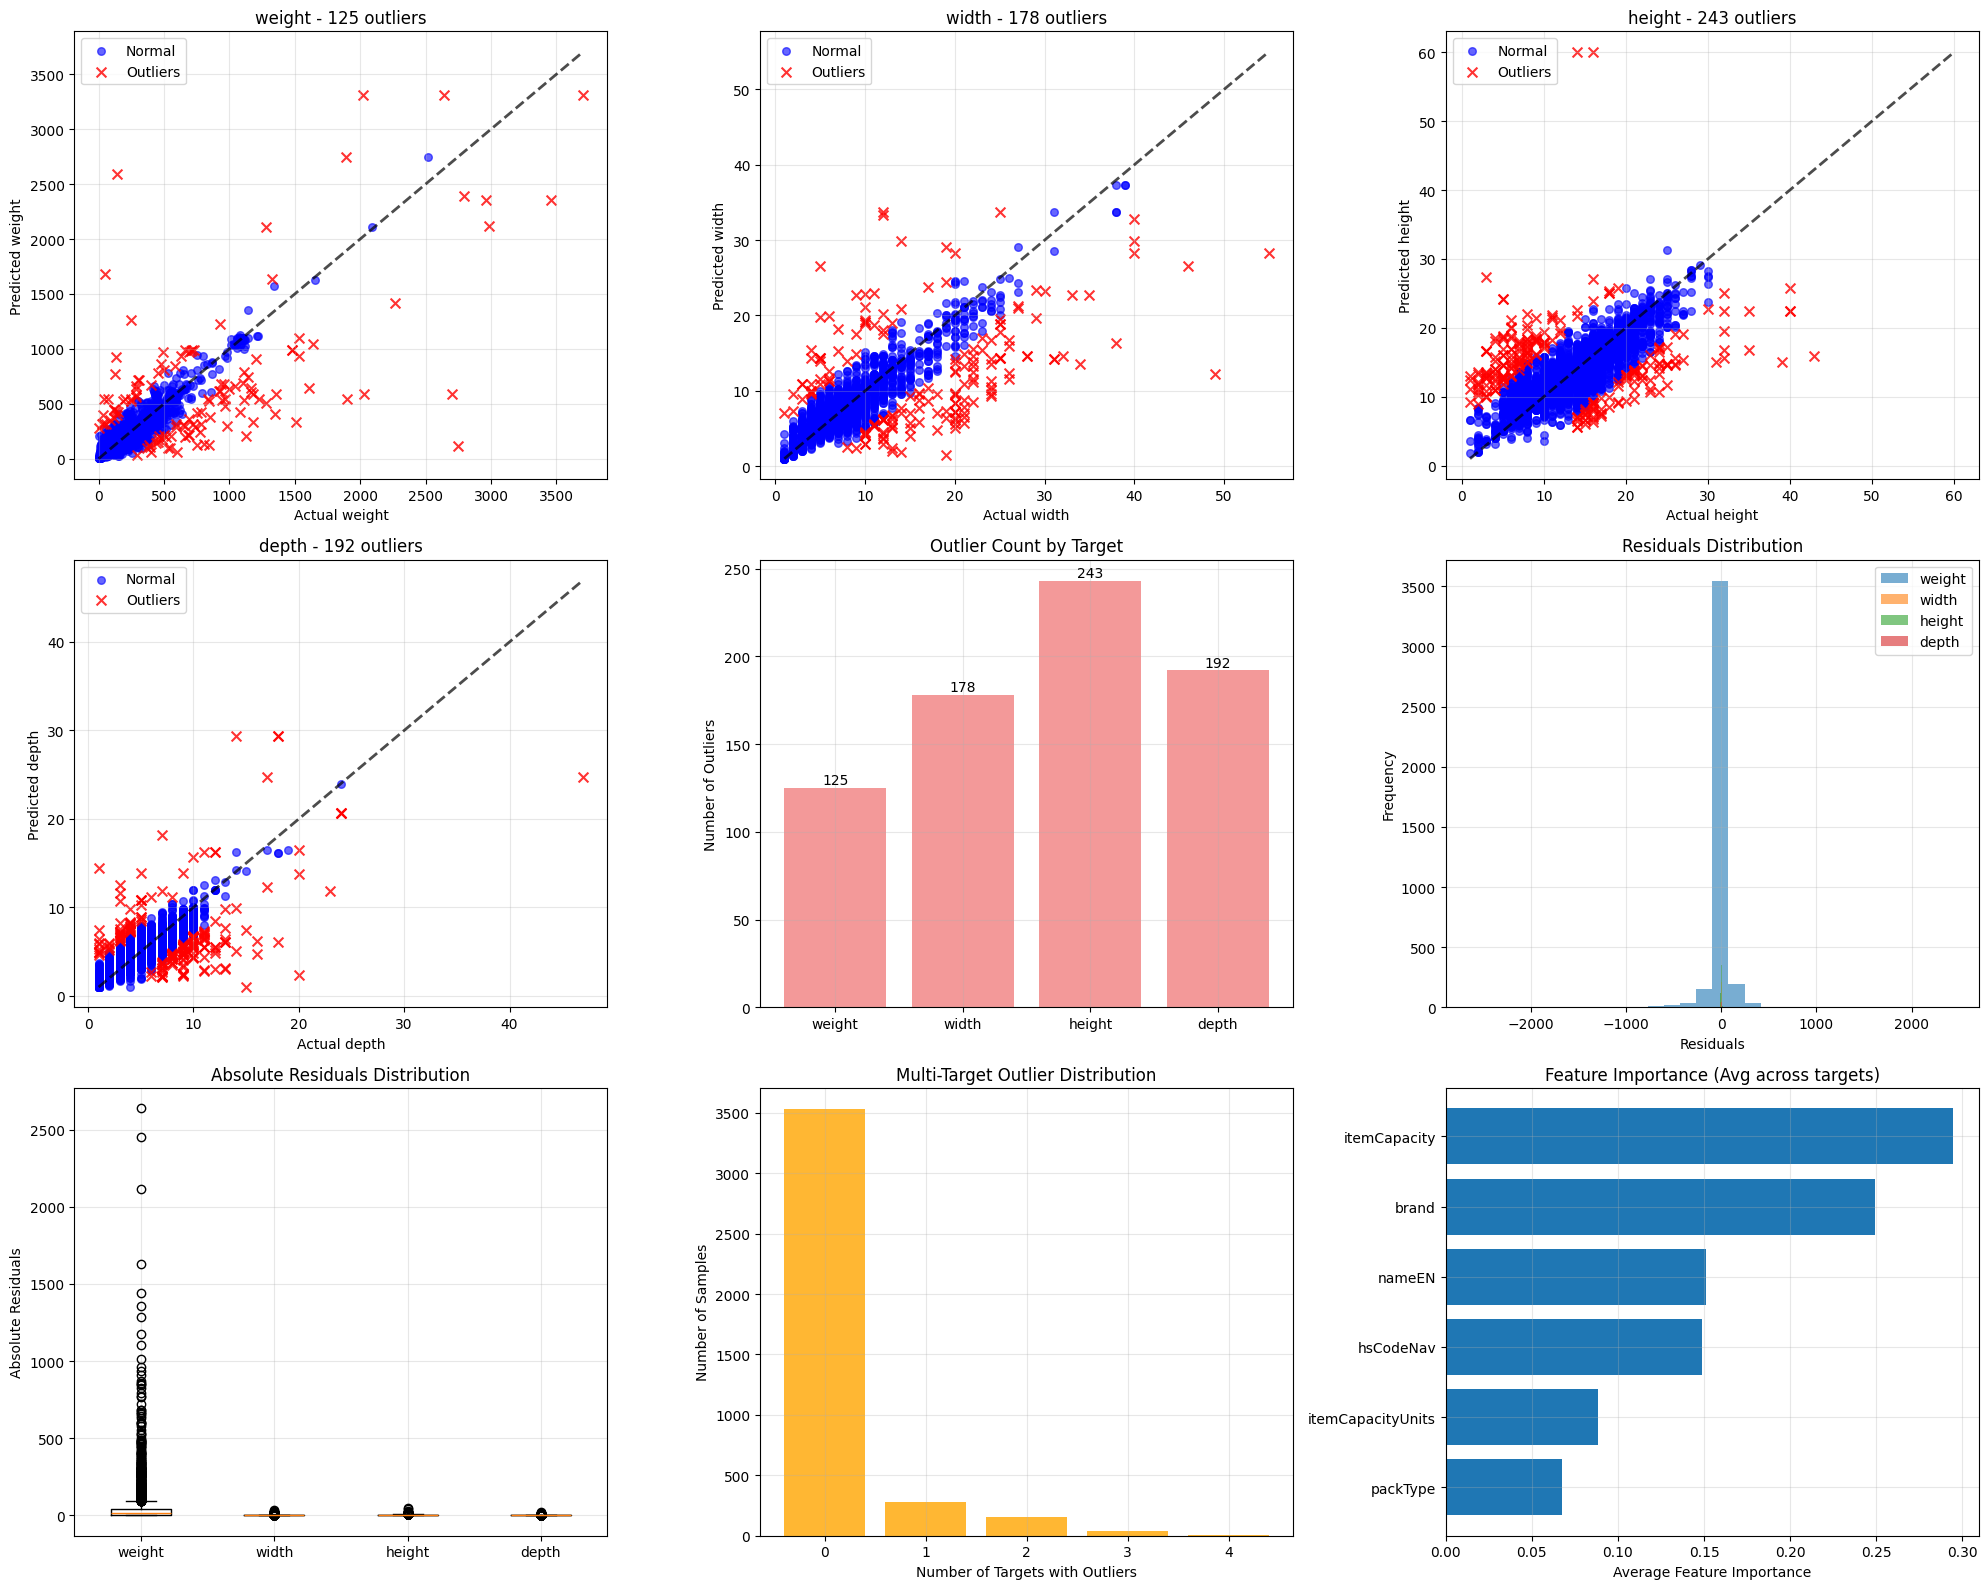

In [ ]:
# 9. Visualizations
print(f"\n📊 Generating outlier visualizations...")

def plot_outlier_analysis():
    """Create comprehensive outlier visualization"""
    
    fig = plt.figure(figsize=(20, 16))
    
    # Plot 1-4: Predictions vs Actual with outliers highlighted
    for i, target in enumerate(targets):
        ax = plt.subplot(3, 3, i+1)
        
        # Normal predictions
        normal_mask = ~outlier_masks[target]
        ax.scatter(y_test.iloc[normal_mask, i], y_pred[normal_mask, i], 
                  alpha=0.6, color='blue', label='Normal', s=30)
        
        # Outlier predictions
        outlier_mask = outlier_masks[target]
        if np.sum(outlier_mask) > 0:
            ax.scatter(y_test.iloc[outlier_mask, i], y_pred[outlier_mask, i], 
                      alpha=0.8, color='red', label='Outliers', s=50, marker='x')
        
        # Perfect prediction line
        min_val = min(y_test.iloc[:, i].min(), y_pred[:, i].min())
        max_val = max(y_test.iloc[:, i].max(), y_pred[:, i].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.7, linewidth=2)
        
        # Formatting
        ax.set_xlabel(f'Actual {target}')
        ax.set_ylabel(f'Predicted {target}')
        ax.set_title(f'{target} - {np.sum(outlier_mask)} outliers')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Plot 5: Outlier counts by target
    ax5 = plt.subplot(3, 3, 5)
    outlier_counts_list = [outlier_counts[target]['count'] for target in targets]
    bars = ax5.bar(targets, outlier_counts_list, color='lightcoral', alpha=0.8)
    ax5.set_ylabel('Number of Outliers')
    ax5.set_title('Outlier Count by Target')
    ax5.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar, count in zip(bars, outlier_counts_list):
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{count}', ha='center', va='bottom')
    
    # Plot 6: Residuals distribution
    ax6 = plt.subplot(3, 3, 6)
    for i, target in enumerate(targets):
        ax6.hist(residuals[:, i], bins=30, alpha=0.6, label=target)
    ax6.set_xlabel('Residuals')
    ax6.set_ylabel('Frequency')
    ax6.set_title('Residuals Distribution')
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    
    # Plot 7: Absolute residuals boxplot
    ax7 = plt.subplot(3, 3, 7)
    abs_residuals_list = [abs_residuals[:, i] for i in range(len(targets))]
    ax7.boxplot(abs_residuals_list, labels=targets)
    ax7.set_ylabel('Absolute Residuals')
    ax7.set_title('Absolute Residuals Distribution')
    ax7.grid(True, alpha=0.3)
    
    # Plot 8: Multi-target outlier analysis
    ax8 = plt.subplot(3, 3, 8)
    outlier_count_dist = outlier_df['Outlier_Count'].value_counts().sort_index()
    ax8.bar(outlier_count_dist.index, outlier_count_dist.values, color='orange', alpha=0.8)
    ax8.set_xlabel('Number of Targets with Outliers')
    ax8.set_ylabel('Number of Samples')
    ax8.set_title('Multi-Target Outlier Distribution')
    ax8.set_xticks(range(5))  # 0, 1, 2, 3, 4 targets
    ax8.grid(True, alpha=0.3)
    
    # Plot 9: Feature importance for best model
    ax9 = plt.subplot(3, 3, 9)
    
    # Get feature importance from the best model
    try:
        # Average feature importance across all targets
        importances = []
        for i in range(len(targets)):
            estimator = best_model.named_steps['regressor'].estimators_[i]
            importances.append(estimator.feature_importances_)
        
        avg_importance = np.mean(importances, axis=0)
        feature_importance_df = pd.DataFrame({
            'Feature': features,
            'Importance': avg_importance
        }).sort_values('Importance', ascending=True)
        
        ax9.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
        ax9.set_xlabel('Average Feature Importance')
        ax9.set_title('Feature Importance (Avg across targets)')
        ax9.grid(True, alpha=0.3)
        
    except Exception as e:
        ax9.text(0.5, 0.5, f'Feature importance\nnot available:\n{str(e)}', 
                ha='center', va='center', transform=ax9.transAxes)
        ax9.set_title('Feature Importance')
    
    plt.tight_layout()
    plt.show()

# Generate plots
plot_outlier_analysis()

In [ ]:
# 10. Export Outlier Data
print(f"\n💾 OUTLIER DATA EXPORT:")
print("="*30)

# Create summary statistics
outlier_summary = {
    'Total_Samples': len(outlier_df),
    'Total_Outliers': len(outlier_df[outlier_df['IsOutlier_Any'] == True]),
    'Outlier_Percentage': len(outlier_df[outlier_df['IsOutlier_Any'] == True]) / len(outlier_df) * 100,
    'Method': OUTLIER_METHOD,
    'Threshold': OUTLIER_THRESHOLD
}

for target in targets:
    outlier_summary[f'{target}_Outliers'] = outlier_counts[target]['count']
    outlier_summary[f'{target}_Outlier_Percentage'] = outlier_counts[target]['percentage']

print("Outlier Summary:")
for key, value in outlier_summary.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.2f}")
    else:
        print(f"  {key}: {value}")

# Optional: Save to CSV files
save_to_csv = True  # Set to True if you want to save files

if save_to_csv:
    print(f"\n💾 Saving outlier data to CSV files...")
    
    # Save all outlier data
    outlier_df.to_csv('outlier_analysis_full.csv', index=False)
    print("✅ Saved: outlier_analysis_full.csv")
    
    # Save only outliers
    outliers_only = outlier_df[outlier_df['IsOutlier_Any'] == True]
    outliers_only.to_csv('outliers_only.csv', index=False)
    print(f"✅ Saved: outliers_only.csv ({len(outliers_only)} outliers)")
    
    # Save outlier summary
    pd.DataFrame([outlier_summary]).to_csv('outlier_summary.csv', index=False)
    print("✅ Saved: outlier_summary.csv")

print(f"\n🎯 PIPELINE COMPLETED!")
print(f"Model R² Score: {overall_r2:.4f}")
print(f"Total Outliers Found: {len(outlier_df[outlier_df['IsOutlier_Any'] == True])}")
print(f"Outlier Detection Method: {OUTLIER_METHOD} (threshold: {OUTLIER_THRESHOLD})")

# Quick access to outlier lists
print(f"\n📋 QUICK ACCESS TO OUTLIER LISTS:")
print("="*40)
print("Variables created for further analysis:")
print("• outlier_df: Complete dataframe with outlier flags")
print("• outlier_masks: Dictionary of outlier masks by target")
print("• outliers_any: Dataframe of rows that are outliers in any target")
print("• multi_outliers: Dataframe of rows that are outliers in 2+ targets")
print("\nExample usage:")
print("• View all outliers: outlier_df[outlier_df['IsOutlier_Any'] == True]")
print("• View weight outliers: outlier_df[outlier_df['IsOutlier_weight'] == True]")
print("• Get outlier indices: outlier_df[outlier_df['IsOutlier_Any'] == True]['Index'].tolist()")


💾 OUTLIER DATA EXPORT:
Outlier Summary:
  Total_Samples: 4013
  Total_Outliers: 484
  Outlier_Percentage: 12.06
  Method: std_dev
  Threshold: 2
  weight_Outliers: 125
  weight_Outlier_Percentage: 3.11
  width_Outliers: 178
  width_Outlier_Percentage: 4.44
  height_Outliers: 243
  height_Outlier_Percentage: 6.06
  depth_Outliers: 192
  depth_Outlier_Percentage: 4.78

💾 Saving outlier data to CSV files...
✅ Saved: outlier_analysis_full.csv
✅ Saved: outliers_only.csv (484 outliers)
✅ Saved: outlier_summary.csv

🎯 PIPELINE COMPLETED!
Model R² Score: 0.6447
Total Outliers Found: 484
Outlier Detection Method: std_dev (threshold: 2)

📋 QUICK ACCESS TO OUTLIER LISTS:
Variables created for further analysis:
• outlier_df: Complete dataframe with outlier flags
• outlier_masks: Dictionary of outlier masks by target
• outliers_any: Dataframe of rows that are outliers in any target
• multi_outliers: Dataframe of rows that are outliers in 2+ targets

Example usage:
• View all outliers: outlier_df[o